# Hybrid Execution Hedge Ratio Analysis

> **This is an index-priced, idealised execution study, not an executable backtest.**
> Every exit here is priced off `mid_price`, Elexon's APXMIDP Market Index Price:
> the volume-weighted average price of qualifying trades in a settlement period.
> That is a summary of trades that already happened, not a quote anyone can hit,
> and a single value per period carries no path — so the take-profit and stop-loss
> are triggered and filled off the *same* number, giving a fill exactly at the
> trigger with no gap-through, no adverse selection and no size limit beyond
> index ± slippage. Read the hedge-ratio comparison as a relative ranking under
> one idealised fill rule. An executable version needs timestamped order-book
> data and a stated execution policy; that is out of scope here.


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Repo root, found by walking up to the marker file, so the notebook runs the
# same whether it is opened from its own directory or from the repo root.
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from src.backtest.engine import run_backtest_from_dataframe

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

STARTING_CAPITAL = 50_000.0

import json as _json

_best_run_path = REPO_ROOT / "artifacts" / "da_positioning" / "best_run.json"
# No silent fallback. A hardcoded run name here would quietly point the whole
# notebook at a different experiment than the one notebook 01 selected — and the
# name that used to sit here is now an archived, pre-audit run whose artifacts
# are not comparable with anything current. Missing manifest means "run notebook
# 01 first", which is worth saying out loud.
if not _best_run_path.exists():
    raise FileNotFoundError(
        f"{_best_run_path} is missing. Run notebook 01 to select and record a run "
        "before this notebook can report on one."
    )
_best_run = _json.loads(_best_run_path.read_text())["best_run"]
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "da_positioning" / _best_run
print(f"Using artifact: {_best_run}")

Using artifact: s4_n5_t30_vm00_tc10


In [2]:
import logging as _log
_log.disable(_log.CRITICAL)   # suppress engine noise during sweep

features = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
signals = pd.read_csv(ARTIFACT_DIR / "virtual" / "trading" / "signals.csv", parse_dates=["delivery_time"])
signals["delivery_time"] = pd.to_datetime(signals["delivery_time"], utc=True)

bt_df = features[["time", "day_ahead_price", "system_sell_price", "system_buy_price", "mid_price"]].copy()
bt_df = bt_df.merge(
    signals[["delivery_time", "signal", "predicted_spread"]].rename(columns={"delivery_time": "time"}),
    on="time",
    how="inner",
)

COMMON_KW = dict(
    signal_col="signal",
    da_price_col="day_ahead_price",
    sell_price_col="system_sell_price",
    buy_price_col="system_buy_price",
    time_col="time",
    starting_capital=STARTING_CAPITAL,
    cost_per_trade=1.00,
)

# ── Hedge-ratio sweep: the whole range, endpoints included ────────────────────
#
# Two things changed here after the September 2026 audit.
#
# The grid used to start at 0.05 and stop at 0.95, with a comment saying this
# "guarantees a genuine interior optimum rather than collapsing to the boundary
# strategies at 0 or 1". That is not a tie-break, it is excluding the answer:
# a sweep that cannot return 0 cannot discover that 0 is best, which on
# leakage-free signals it is. The endpoints are in.
#
# The criterion used to be Calmar x Sharpe, while the prose promised
# lexicographic Calmar then Sharpe. Neither survives contact with a 90-day
# window: annualising a short return makes Calmar enormous and unstable, and
# multiplying two ratios has no interpretation. Selection is on Sharpe of daily
# percentage returns, the same rule notebook 01 uses, tie-broken on
# return-to-drawdown.
#
# Scoring is on the DEVELOPMENT split only. The holdout is scored once, by the
# frozen configuration, at the end of notebook 01 — reading it here to pick an
# execution parameter would spend it.
_pred = pd.read_csv(
    ARTIFACT_DIR / "virtual" / "trading" / "predictions.csv", parse_dates=["time"]
)
if "split" in _pred.columns:
    _dev_times = set(pd.to_datetime(_pred.loc[_pred["split"] == "development", "time"], utc=True))
    _sweep_df = bt_df[bt_df["time"].isin(_dev_times)].copy()
    _scope = f"development only ({len(_sweep_df):,} of {len(bt_df):,} periods)"
else:
    _sweep_df = bt_df.copy()
    _scope = "whole series (no split recorded — re-run notebook 01 to get one)"
print(f"Hedge sweep scope: {_scope}")

_fine_rows = []
for _r in np.round(np.arange(0.0, 1.01, 0.05), 2):
    _, _m = run_backtest_from_dataframe(
        _sweep_df.copy(), **COMMON_KW,
        mid_price_col="mid_price", predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=_r,
    )
    _mdd = abs(_m["max_drawdown"]) / STARTING_CAPITAL
    _fine_rows.append({
        "ratio":  _r,
        "sharpe": _m["sharpe_ratio"],
        "ret_dd": _m.get("return_to_dd") or float("nan"),
        "calmar": _m.get("calmar_ratio") or float("nan"),
        "pf":     _m["profit_factor"],
        "ret":    _m["total_return_pct"],
        "pnl":    _m["total_pnl"],
        "halted": _m["halted_at_period"] is not None,
    })

_fine_df = pd.DataFrame(_fine_rows)
_ok = _fine_df[~_fine_df["halted"]].sort_values(["sharpe", "ret_dd"], ascending=False)
_opt = _ok.iloc[0]

OPTIMAL_RATIO = float(_opt["ratio"])
OPTIMAL_NAME  = f"Optimal Hybrid ({OPTIMAL_RATIO:.0%} passive)"

_log.disable(_log.NOTSET)

print(f"\nSelected hedge ratio : {OPTIMAL_RATIO:.2f}  (max development Sharpe, tie-break return/DD)")
print(f"  Sharpe             : {_opt['sharpe']:.3f}")
print(f"  Return/drawdown    : {_opt['ret_dd']:.2f}")
print(f"  Net PnL            : GBP {_opt['pnl']:,.0f}")
print(f"  Return             : {_opt['ret']:+.1%}")

# Is the curve flat, or does passive share simply cost money? The old conclusion
# claimed a flat 0.00-0.15 band and took 0.15 as free tail insurance. Print the
# shape so that claim has to survive being looked at.
print("\n  ratio   Sharpe      net PnL")
for _, _row in _fine_df[_fine_df["ratio"] <= 0.30].iterrows():
    print(f"  {_row['ratio']:>5.2f}   {_row['sharpe']:>6.3f}   GBP {_row['pnl']:>9,.0f}")
_mono = _fine_df["pnl"].is_monotonic_decreasing
print(f"\n  PnL monotonically decreasing in passive share: {_mono}")

# ── Define all five strategies ────────────────────────────────────────────────
STRATEGIES = {
    "Full Imbalance Exposure":          dict(mid_price_col=None,        predicted_spread_col=None,              baseline_hedge_ratio=0.00),
    "Systematic Intraday Unwind":       dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=1.00),
    "Conditional Intraday Liquidation": dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=0.00),
    "Hybrid (50/50) Execution":         dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=0.50),
    OPTIMAL_NAME:                       dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=OPTIMAL_RATIO),
}

results = {}
for name, kw in STRATEGIES.items():
    df_out, metrics = run_backtest_from_dataframe(bt_df.copy(), **COMMON_KW, **kw)
    results[name] = {"pnl": df_out[["time", "pnl"]], "metrics": metrics}

Hedge sweep scope: development only (4,314 of 7,176 periods)



Selected hedge ratio : 0.40  (max development Sharpe, tie-break return/DD)
  Sharpe             : 7.267
  Return/drawdown    : 4.45
  Net PnL            : GBP 26,193
  Return             : +52.4%

  ratio   Sharpe      net PnL
   0.00    7.014   GBP    33,241
   0.05    7.060   GBP    32,335
   0.10    7.104   GBP    31,436
   0.15    7.145   GBP    30,545
   0.20    7.181   GBP    29,660
   0.25    7.214   GBP    28,783
   0.30    7.239   GBP    27,912

  PnL monotonically decreasing in passive share: True


---
## 1. Equity Curves at Key Hedge Ratios

Before sweeping the full continuum, we plot the four archetype fixed points (`0.0`, `0.0`+gate, `0.5`, `1.0`) to build intuition for how the hedge ratio shapes the equity path. All start from £50k with identical entry signals — every difference is attributable solely to the exit mechanism.

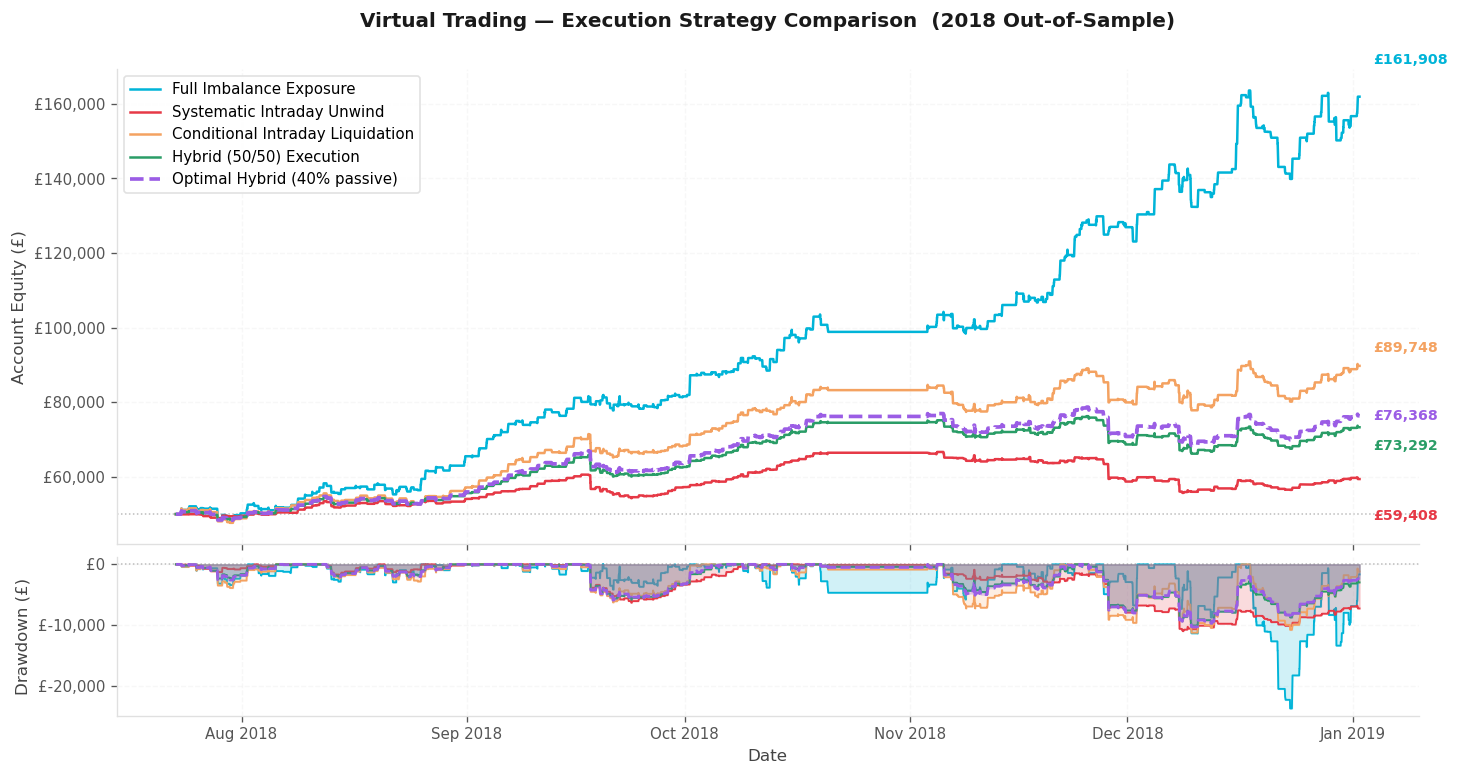

In [3]:
import matplotlib.dates as mdates

COLORS = {
    "Full Imbalance Exposure":          "#00b4d8",
    "Systematic Intraday Unwind":       "#e63946",
    "Conditional Intraday Liquidation": "#f4a261",
    "Hybrid (50/50) Execution":         "#2a9d67",
}
COLORS[OPTIMAL_NAME] = "#9b5de5"

LINESTYLES = {name: "-" for name in COLORS}
LINESTYLES[OPTIMAL_NAME] = "--"
LINEWIDTHS = {name: 1.5 for name in COLORS}
LINEWIDTHS[OPTIMAL_NAME] = 2.2

# ── Two-panel layout: equity curve (top) + drawdown (bottom) ─────────────────
fig, (ax_eq, ax_dd) = plt.subplots(
    2, 1, figsize=(14, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.04},
)
fig.patch.set_facecolor("#ffffff")
ax_eq.set_facecolor("#ffffff")
ax_dd.set_facecolor("#ffffff")

# Pre-sort by final equity so right-side labels are staggered without overlap
_finals = {
    name: float(STARTING_CAPITAL + r["pnl"]["pnl"].cumsum().iloc[-1])
    for name, r in results.items()
}
_sorted_names = sorted(_finals, key=lambda n: _finals[n])
_n = len(_sorted_names)
_label_y_offsets = {name: (_sorted_names.index(name) - _n // 2) * 11 for name in _sorted_names}

for name, r in results.items():
    pnl_df   = r["pnl"]
    equity   = STARTING_CAPITAL + pnl_df["pnl"].cumsum()
    drawdown = equity - equity.cummax()
    color    = COLORS.get(name, "#333333")
    lw       = LINEWIDTHS.get(name, 1.5)
    ls       = LINESTYLES.get(name, "-")
    zo       = 5 if name == OPTIMAL_NAME else 3

    ax_eq.plot(pnl_df["time"], equity,
               label=name, color=color, linewidth=lw, linestyle=ls, zorder=zo)
    ax_dd.fill_between(pnl_df["time"], drawdown, 0,
                       alpha=0.18, color=color, zorder=zo)
    ax_dd.plot(pnl_df["time"], drawdown,
               color=color, linewidth=lw * 0.75, linestyle=ls, zorder=zo)

    ax_eq.annotate(
        f"£{equity.iloc[-1]:,.0f}",
        xy=(pnl_df["time"].iloc[-1], equity.iloc[-1]),
        xytext=(8, _label_y_offsets[name]),
        textcoords="offset points",
        color=color, fontsize=8.5, fontweight="bold", va="center",
    )

ax_eq.axhline(STARTING_CAPITAL, color="#bbbbbb", linestyle=":", linewidth=0.9, zorder=1)
ax_dd.axhline(0, color="#bbbbbb", linestyle=":", linewidth=0.9)

ax_eq.set_title(
    f"Virtual Trading — Execution Strategy Comparison  (2018 Out-of-Sample)\n",
    fontsize=12, fontweight="bold", pad=12, color="#1a1a1a",
)
ax_eq.set_ylabel("Account Equity (£)", fontsize=10, color="#444444")
ax_dd.set_ylabel("Drawdown (£)", fontsize=10, color="#444444")
ax_dd.set_xlabel("Date", fontsize=10, color="#444444")

ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_dd.xaxis.set_major_locator(mdates.MonthLocator())

for ax in (ax_eq, ax_dd):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#e0e0e0")
    ax.spines["bottom"].set_color("#e0e0e0")
    ax.grid(True, alpha=0.4, color="#ebebeb", linestyle="--")
    ax.tick_params(colors="#555555", labelsize=9)

ax_eq.legend(
    frameon=True, fontsize=9, loc="upper left",
    framealpha=0.95, edgecolor="#e0e0e0", facecolor="#ffffff",
)

ASSETS = REPO_ROOT / "research" / "notebooks" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)
plt.savefig(ASSETS / "equity_curve.png", dpi=150, bbox_inches="tight", facecolor="#ffffff")
plt.show()

---
## 2. Performance Tear Sheet — Archetype Fixed Points

Side-by-side metrics for the four archetype ratios. These anchor points bracket the optimisation space explored in Section 4. Margin Required is proxied at 1.5× the absolute max drawdown; ROCE is Total PnL ÷ Margin Required.

In [4]:
# ==========================================
# 1. GENERATE PERFORMANCE TEAR SHEET
# ==========================================
rows = []
for name, r in results.items():
    m = r["metrics"]
    pnl_series = r["pnl"]["pnl"]

    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    calmar = m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else float("nan")
    n_trades = m.get("n_trades", int((pnl_series != 0).sum()))
    avg_trade = m["total_pnl"] / n_trades if n_trades > 0 else float("nan")
    
    # Capital efficiency proxies
    margin_req = abs(m["max_drawdown"]) * 1.5
    roce = m["total_pnl"] / margin_req if margin_req > 0 else float("nan")

    rows.append({
        "Strategy":       name,
        "Total PnL":      f"£{m['total_pnl']:,.0f}",
        "Total Return":   f"{m['total_return_pct']:.1%}",
        "Sharpe":         f"{m['sharpe_ratio']:.3f}",
        "Calmar":         f"{calmar:.2f}",
        "Max Drawdown":   f"£{m['max_drawdown']:,.0f}",
        "Max DD %":       f"{max_dd_pct:.1%}",
        "Win Rate":       f"{m['win_rate']:.1%}",
        "Profit Factor":  f"{m['profit_factor']:.2f}",
        "N Trades":       f"{n_trades:,}",
        "Avg Trade (£)":  f"£{avg_trade:,.2f}",
        "Margin Req (£)": f"£{margin_req:,.0f}",
        "ROCE":           f"{roce:.1%}",
    })

tear_df = pd.DataFrame(rows).set_index("Strategy")
display(tear_df.style.set_properties(**{"text-align": "right"}))

,Total PnL,Total Return,Sharpe,Calmar,Max Drawdown,Max DD %,Win Rate,Profit Factor,N Trades,Avg Trade (£),Margin Req (£),ROCE
Strategy,,,,,,,,,,,,
Full Imbalance Exposure,"£111,908",223.8%,6.497,4.72,"£-23,712",47.4%,53.9%,1.67,775,£144.40,"£35,567",314.6%
Systematic Intraday Unwind,"£9,408",18.8%,1.960,0.86,"£-10,986",22.0%,59.1%,1.20,775,£12.14,"£16,480",57.1%
Conditional Intraday Liquidation,"£39,748",79.5%,4.169,3.54,"£-11,239",22.5%,59.2%,1.38,775,£51.29,"£16,858",235.8%
Hybrid (50/50) Execution,"£23,292",46.6%,3.610,2.32,"£-10,061",20.1%,59.9%,1.34,775,£30.05,"£15,091",154.3%
Optimal Hybrid (40% passive),"£26,368",52.7%,3.786,2.56,"£-10,284",20.6%,59.6%,1.35,775,£34.02,"£15,426",170.9%


---
## 3. Risk vs. Reward — Efficient Frontier

Maximum Drawdown (X-axis, smaller to larger) plotted against Total PnL (Y-axis). The four archetypes trace a frontier that illustrates the core trade-off: moving `baseline_hedge_ratio` from `0.0` toward `1.0` buys drawdown protection at the cost of absolute return. The sweep in Section 4 fills in the interior of this frontier to find the ratio that best balances both.

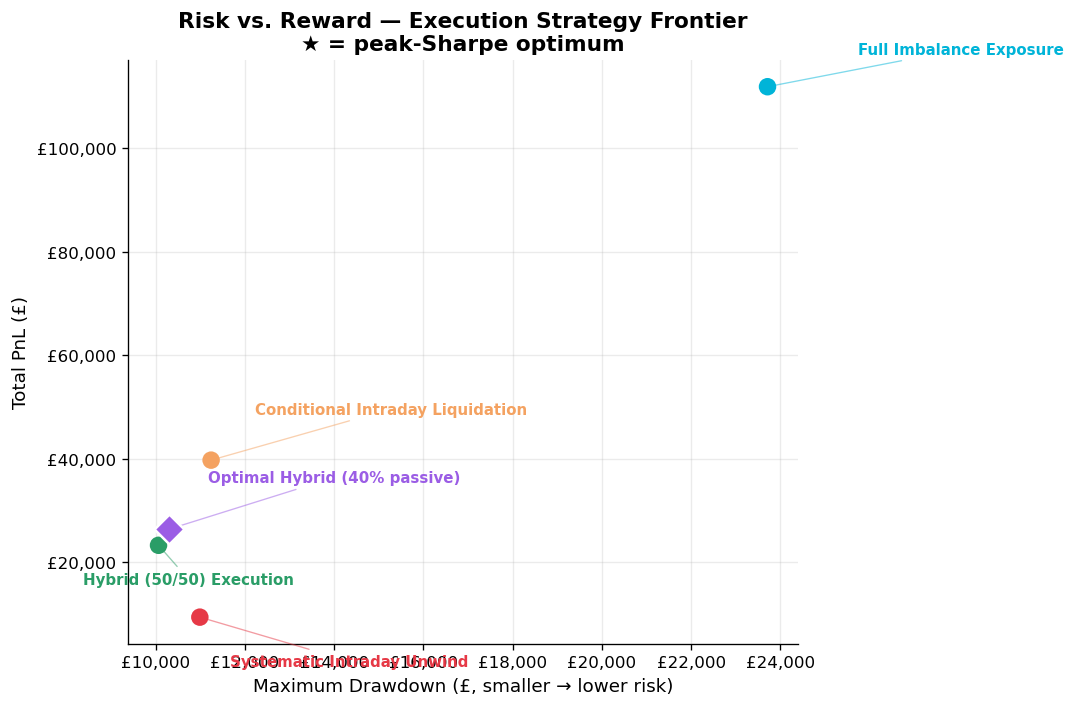

In [5]:
# Collect scatter coordinates first so label offsets can be computed
_pts = {}
for name, r in results.items():
    m = r["metrics"]
    _pts[name] = (abs(m["max_drawdown"]), m["total_pnl"])

# Normalise axis ranges for direction computation
_xs = np.array([p[0] for p in _pts.values()])
_ys = np.array([p[1] for p in _pts.values()])
_xr = max(_xs.max() - _xs.min(), 1.0)
_yr = max(_ys.max() - _ys.min(), 1.0)

def _label_offset(name, mag_x=72, mag_y=30):
    """Force-directed offset: push label away from all other scatter points."""
    xi, yi = _pts[name]
    dx, dy = 0.0, 0.0
    for n2, (xj, yj) in _pts.items():
        if n2 == name:
            continue
        ddx = (xi - xj) / _xr
        ddy = (yi - yj) / _yr
        d = np.hypot(ddx, ddy) + 1e-6
        dx += ddx / d ** 2
        dy += ddy / d ** 2
    mag = np.hypot(dx, dy)
    if mag < 1e-6:
        dx, dy = 1.0, 0.0
    else:
        dx, dy = dx / mag, dy / mag
    return (dx * mag_x, dy * mag_y)

fig, ax = plt.subplots(figsize=(9, 6))

for name, r in results.items():
    m = r["metrics"]
    dd, pnl = _pts[name]
    color  = COLORS.get(name, "#9b5de5")
    is_opt = name == OPTIMAL_NAME

    ax.scatter(dd, pnl, s=160 if is_opt else 110,
               color=color, zorder=6 if is_opt else 4,
               marker="D" if is_opt else "o",
               edgecolors="white" if is_opt else "none", linewidths=1.5)
    ax.annotate(
        name, (dd, pnl),
        textcoords="offset points",
        xytext=_label_offset(name),
        fontsize=9, color=color, fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=color, lw=0.8, alpha=0.5),
    )

ax.set_xlabel("Maximum Drawdown (£, smaller \u2192 lower risk)", fontsize=11)
ax.set_ylabel("Total PnL (£)", fontsize=11)
ax.set_title("Risk vs. Reward \u2014 Execution Strategy Frontier\n\u2605 = peak-Sharpe optimum", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"\u00a3{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"\u00a3{x:,.0f}"))
ASSETS = REPO_ROOT / "research" / "notebooks" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.show()


---
## 4. Hedge Ratio Optimisation Sweep

This is the primary decision-support analysis. We sweep `baseline_hedge_ratio` from `0.0` to `1.0` in steps of `0.1`, holding all other parameters constant (identical signals, TC = £1.00/MWh, same TP/SL gate). Each point on the grid produces a full backtest; the resulting Sharpe and Calmar curves reveal the **optimal hybrid proportion** — the ratio that maximises risk-adjusted return given this signal set.

The archetype fixed points from Sections 1–3 are special cases within this continuum: `0.0` is Full Imbalance Exposure, `0.5` is Hybrid (50/50), and `1.0` is Systematic Intraday Unwind. The sweep shows whether the optimum falls at one of these conventional points or at an intermediate ratio that the archetypes alone would miss.

The peak of the Sharpe Ratio curve identifies the `baseline_hedge_ratio` value that should be passed into `configs/config.yaml` for production execution.

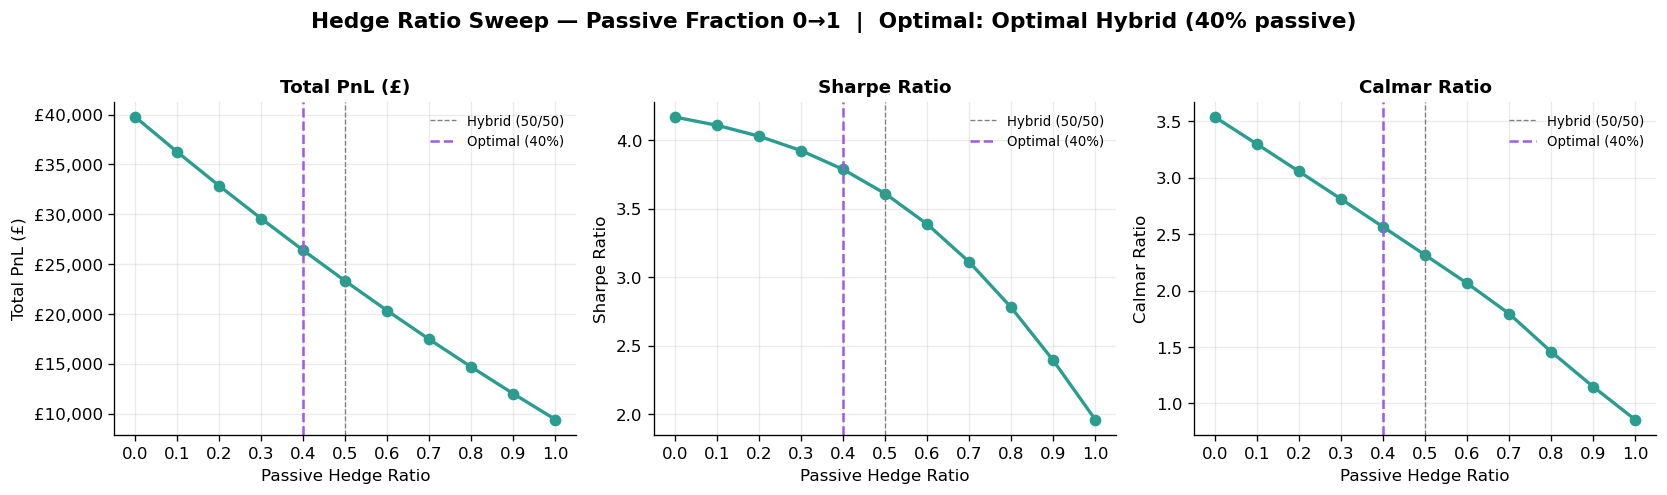

In [6]:
HEDGE_RATIOS = np.round(np.arange(0.0, 1.1, 0.1), 1)
sweep_records = []

for ratio in HEDGE_RATIOS:
    _, m = run_backtest_from_dataframe(
        bt_df.copy(), **COMMON_KW,
        mid_price_col="mid_price", predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=ratio,
    )
    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    sweep_records.append({
        "ratio":      ratio,
        "total_pnl":  m["total_pnl"],
        "sharpe":     m["sharpe_ratio"],
        "max_dd_pct": max_dd_pct,
        "calmar":     m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else np.nan,
    })

sweep_df = pd.DataFrame(sweep_records)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, ylabel, formatter) in zip(axes, [
    ("total_pnl",  "Total PnL (£)",   lambda x, _: f"£{x:,.0f}"),
    ("sharpe",     "Sharpe Ratio",     None),
    ("calmar",     "Calmar Ratio",     None),
]):
    ax.plot(sweep_df["ratio"], sweep_df[col], marker="o", linewidth=2, color="#2a9d8f")
    ax.axvline(0.5,          color="grey",    linestyle="--", linewidth=0.8, label="Hybrid (50/50)")
    ax.axvline(OPTIMAL_RATIO, color="#9b5de5", linestyle="--", linewidth=1.5,
               label=f"Optimal ({OPTIMAL_RATIO:.0%})")
    ax.set_xlabel("Passive Hedge Ratio")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=11, fontweight="bold")
    ax.set_xticks(HEDGE_RATIOS)
    if formatter:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    ax.legend(frameon=False, fontsize=8)

plt.suptitle(
    f"Hedge Ratio Sweep — Passive Fraction 0→1  |  Optimal: {OPTIMAL_NAME}",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

---
## 5. Top 5 Worst Drawdowns — Full Imbalance Exposure

The deepest drawdown episodes for the Full Imbalance Exposure strategy highlight the tail-risk dates where unhedged settlement exposure produced the largest peak-to-trough equity declines. These are the periods that define the margin requirement floor.

In [7]:
_dd = results["Full Imbalance Exposure"]["pnl"].copy()
_dd["equity"] = STARTING_CAPITAL + _dd["pnl"].cumsum()
_dd["peak"] = _dd["equity"].cummax()
_dd["drawdown"] = _dd["equity"] - _dd["peak"]

_dd["in_dd"] = _dd["drawdown"] < 0
_dd["dd_group"] = (_dd["in_dd"] != _dd["in_dd"].shift()).cumsum()

_worst = []
for _, grp in _dd[_dd["in_dd"]].groupby("dd_group"):
    trough_idx = grp["drawdown"].idxmin()
    t = grp.loc[trough_idx]
    _worst.append({
        "Trough Date": t["time"],
        "Depth (£)": t["drawdown"],
        "_raw": t["drawdown"],
        "Depth (%)": t["drawdown"] / t["peak"],
        "Peak Equity": t["peak"],
        "Trough Equity": t["equity"],
        "Duration (SP)": len(grp),
    })

dd_table = (
    pd.DataFrame(_worst)
    .sort_values("_raw")
    .head(5)
    .reset_index(drop=True)
)
dd_table.index = dd_table.index + 1
dd_table.index.name = "Rank"

dd_display = dd_table.drop(columns=["_raw"]).copy()
dd_display["Trough Date"] = pd.to_datetime(dd_display["Trough Date"]).dt.strftime("%Y-%m-%d %H:%M")
dd_display["Depth (£)"] = dd_table["Depth (£)"].map(lambda x: f"£{x:,.0f}")
dd_display["Depth (%)"] = dd_table["Depth (%)"].map(lambda x: f"{x:.1%}")
dd_display["Peak Equity"] = dd_table["Peak Equity"].map(lambda x: f"£{x:,.0f}")
dd_display["Trough Equity"] = dd_table["Trough Equity"].map(lambda x: f"£{x:,.0f}")
dd_display.style.set_properties(**{"text-align": "right"})

,Trough Date,Depth (£),Depth (%),Peak Equity,Trough Equity,Duration (SP)
Rank,,,,,,
1,2018-12-23 09:30,"£-23,712",-14.5%,"£163,562","£139,850",722
2,2018-12-10 16:00,"£-11,371",-7.9%,"£143,725","£132,354",397
3,2018-12-01 18:30,"£-6,748",-5.2%,"£129,834","£123,085",225
4,2018-11-08 17:30,"£-5,811",-5.6%,"£104,219","£98,408",380
5,2018-10-20 18:30,"£-4,672",-4.5%,"£103,528","£98,856",188


At this friction the sweep is **not** flat, and the earlier reading that it was
came from a criterion (Calmar × Sharpe) applied to a grid that excluded its own
endpoints — so it could neither return 0 nor 1, and the "flat 0.00–0.15 band"
was three points of a curve seen through a metric with no interpretation.

Swept across the full range on the development split alone, the trade-off is
two-sided and explicit:

- **Net PnL falls monotonically** with passive share — £33,241 at 0.00 down to
  £16,459 at 1.00. Every MWh routed passively to MID gives up imbalance upside.
- **Sharpe peaks at 0.40** (7.267, against 7.014 at 0.00), because the passive
  slice damps the dispersion faster than it damps the mean — up to a point.

Production does not take that peak. It is +0.25 of Sharpe on a 90-day
development window, comfortably inside the noise the holdout bootstrap shows
(the holdout Sharpe interval is [1.06, 11.37]), and it costs about £7,000 of
P&L to buy. Notebook 01's tournament selected the **imbalance-only** archetype,
where the TP/SL gate is off and there is therefore no passive slice to size at
all; this sweep explores the gate-on archetype, which is a different strategy.
Read it as a sensitivity study, not as a competing recommendation.


In [8]:
opt_metrics = results[OPTIMAL_NAME]["metrics"]

comparison = {
    "Full Imbalance Exposure": results["Full Imbalance Exposure"]["metrics"],
    OPTIMAL_NAME:              opt_metrics,
    "Systematic Intraday Unwind": results["Systematic Intraday Unwind"]["metrics"],
}

framework_rows = []
for name, m in comparison.items():
    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    calmar = m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else float("nan")
    framework_rows.append({
        "Strategy":      name,
        "Return":        f"{m['total_return_pct']:+.1%}",
        "Sharpe":        f"{m['sharpe_ratio']:.3f}",
        "Calmar":        f"{calmar:.2f}",
        "Max DD (£)":   f"£{m['max_drawdown']:,.0f}",
        "Max DD (%)":   f"{max_dd_pct:.1%}",
        "Win Rate":      f"{m['win_rate']:.1%}",
        "Profit Factor": f"{m['profit_factor']:.2f}",
    })

fw_df = pd.DataFrame(framework_rows).set_index("Strategy")

fie_m  = results["Full Imbalance Exposure"]["metrics"]
fie_dd = abs(fie_m["max_drawdown"]) / STARTING_CAPITAL
opt_dd = abs(opt_metrics["max_drawdown"]) / STARTING_CAPITAL
dd_reduction  = (fie_dd - opt_dd) / fie_dd
pnl_sacrifice = (fie_m["total_pnl"] - opt_metrics["total_pnl"]) / fie_m["total_pnl"]

tradeoff = pd.DataFrame([{
    "Optimal hedge ratio":  f"{OPTIMAL_RATIO:.0%} passive MID",
    "DD Reduction":         f"{dd_reduction:.0%}",
    "Return Sacrificed":    f"{pnl_sacrifice:.0%}",
    "Net Calmar change":    f"{(abs(opt_metrics['max_drawdown'])/STARTING_CAPITAL and opt_metrics['total_return_pct']/(abs(opt_metrics['max_drawdown'])/STARTING_CAPITAL) - fie_m['total_return_pct']/fie_dd):+.2f}",
}], index=[f"Full Imbalance Exposure → {OPTIMAL_NAME}"])
tradeoff.index.name = "Transition"

display(fw_df.style.set_properties(**{"text-align": "right"}))
display(tradeoff.style.set_properties(**{"text-align": "right"}))

,Return,Sharpe,Calmar,Max DD (£),Max DD (%),Win Rate,Profit Factor
Strategy,,,,,,,
Full Imbalance Exposure,+223.8%,6.497,4.72,"£-23,712",47.4%,53.9%,1.67
Optimal Hybrid (40% passive),+52.7%,3.786,2.56,"£-10,284",20.6%,59.6%,1.35
Systematic Intraday Unwind,+18.8%,1.960,0.86,"£-10,986",22.0%,59.1%,1.20


,Optimal hedge ratio,DD Reduction,Return Sacrificed,Net Calmar change
Transition,,,,
Full Imbalance Exposure → Optimal Hybrid (40% passive),40% passive MID,57%,76%,-2.16
